<a href="https://colab.research.google.com/github/isnale/PROBABILIDAD/blob/main/Unidad1/Pr%C3%A1ctica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Probabilidad y estadística**
##**Unidad 1**
###**Práctica 3, Tabla de frecuencias y regla de Sturges**
###Docente: *Dr. José Gabriel Rodríguez Rivas*
###Alumno: Ximena Valentina Gil Rivas

In [1]:
#Creamos lista que representa la edad de 100 personas
import random
edades = []
for i in range(100):
  numero_aleatorio = random.randint(18,70)
  edades.append(numero_aleatorio)
print(edades)

[41, 42, 47, 29, 24, 30, 25, 26, 63, 44, 50, 52, 56, 22, 25, 18, 57, 66, 41, 64, 48, 59, 19, 68, 33, 25, 39, 19, 30, 68, 44, 61, 52, 22, 44, 62, 62, 54, 35, 49, 52, 30, 21, 21, 63, 18, 23, 23, 18, 44, 22, 22, 44, 55, 66, 18, 39, 46, 22, 40, 42, 63, 54, 51, 47, 49, 64, 36, 59, 46, 52, 63, 57, 44, 50, 70, 35, 53, 51, 19, 20, 60, 24, 54, 61, 66, 24, 63, 69, 62, 23, 64, 25, 29, 63, 56, 69, 35, 38, 63]


In [2]:
import pandas as pd

df=pd.DataFrame(edades,columns=['Edad'])
df.head()

,Edad
0,41
1,42
2,47
3,29
4,24


In [3]:
#Tabla de frecuencias
tabla_frecuencias =  df['Edad'].value_counts().reset_index()
tabla_frecuencias.columns = ['Edad', 'Frecuencia']
tabla_frecuencias = tabla_frecuencias.sort_values(by='Edad')

print("Tabla de distribución de Frecuencias:")
tabla_frecuencias

Tabla de distribución de Frecuencias:


,Edad,Frecuencia
5,18,4
14,19,3
39,20,1
18,21,2
2,22,5
11,23,3
8,24,3
3,25,4
31,26,1
16,29,2


In [4]:
#Frecuencia relativa
tabla_frecuencias['Frec Relativa'] = tabla_frecuencias['Frecuencia'] / 100
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa
5,18,4,0.04
14,19,3,0.03
39,20,1,0.01
18,21,2,0.02
2,22,5,0.05
11,23,3,0.03
8,24,3,0.03
3,25,4,0.04
31,26,1,0.01
16,29,2,0.02


In [5]:
#Frecuencia porcentual
tabla_frecuencias ['Frec Porcentual'] = tabla_frecuencias['Frecuencia']/100 * 100
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa,Frec Porcentual
5,18,4,0.04,4.0
14,19,3,0.03,3.0
39,20,1,0.01,1.0
18,21,2,0.02,2.0
2,22,5,0.05,5.0
11,23,3,0.03,3.0
8,24,3,0.03,3.0
3,25,4,0.04,4.0
31,26,1,0.01,1.0
16,29,2,0.02,2.0


In [6]:
#Frecuencia acumulada
tabla_frecuencias['Frec Acumulada'] = tabla_frecuencias['Frecuencia'].cumsum()
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa,Frec Porcentual,Frec Acumulada
5,18,4,0.04,4.0,4
14,19,3,0.03,3.0,7
39,20,1,0.01,1.0,8
18,21,2,0.02,2.0,10
2,22,5,0.05,5.0,15
11,23,3,0.03,3.0,18
8,24,3,0.03,3.0,21
3,25,4,0.04,4.0,25
31,26,1,0.01,1.0,26
16,29,2,0.02,2.0,28


##Regla de Sturges
1. Es una regla que sirve para calcular el número de clases o intervalos idóneo en los que se debe dividir un conjunto de datos
2. Establece que el número de clases es igual a uno más el logaritmo en base 2 del número total de datos.
N es el tamaño de la muestra

image.png

In [7]:
import math #Librería de funciones matemáticas
print(edades)

[41, 42, 47, 29, 24, 30, 25, 26, 63, 44, 50, 52, 56, 22, 25, 18, 57, 66, 41, 64, 48, 59, 19, 68, 33, 25, 39, 19, 30, 68, 44, 61, 52, 22, 44, 62, 62, 54, 35, 49, 52, 30, 21, 21, 63, 18, 23, 23, 18, 44, 22, 22, 44, 55, 66, 18, 39, 46, 22, 40, 42, 63, 54, 51, 47, 49, 64, 36, 59, 46, 52, 63, 57, 44, 50, 70, 35, 53, 51, 19, 20, 60, 24, 54, 61, 66, 24, 63, 69, 62, 23, 64, 25, 29, 63, 56, 69, 35, 38, 63]


In [8]:
#Creamos data frame con las edades
df = pd.DataFrame({'Edad':edades})
df

,Edad
0,41
1,42
2,47
3,29
4,24
...,...
95,56
96,69
97,35
98,38


In [9]:
#Calcular el número de intervalos con la regla de Sturges
n = len(edades)
k = int(1+math.log2(n))
print("Valor de n =",n)
print("Número de intervalos =",k)

Valor de n = 100
Número de intervalos = 7


In [10]:
#Tabla de frecuencia
tabla_frecuencias = pd.cut(df['Edad'], bins=k, include_lowest=True).value_counts().reset_index()
tabla_frecuencias.columns = ['Clase', 'Frecuencia']
tabla_frecuencias

,Clase,Frecuencia
0,"(17.947, 25.429]",25
1,"(62.571, 70.0]",18
2,"(47.714, 55.143]",16
3,"(40.286, 47.714]",14
4,"(55.143, 62.571]",12
5,"(32.857, 40.286]",9
6,"(25.429, 32.857]",6


In [12]:
#Ordenar la tabla por intervalo
tabla_frecuencias = tabla_frecuencias.sort_values(by='Clase')
tabla_frecuencias

,Clase,Frecuencia
0,"(17.947, 25.429]",25
6,"(25.429, 32.857]",6
5,"(32.857, 40.286]",9
3,"(40.286, 47.714]",14
2,"(47.714, 55.143]",16
4,"(55.143, 62.571]",12
1,"(62.571, 70.0]",18


In [13]:
#Otras columnas
tabla_frecuencias['Frec Relativa'] = tabla_frecuencias['Frecuencia'] / n
tabla_frecuencias['Frec Porcentual'] = tabla_frecuencias['Frecuencia'] / n * 100
tabla_frecuencias['Frec Acumulada'] = tabla_frecuencias['Frecuencia'].cumsum()
tabla_frecuencias['Frec Rel Ac'] = tabla_frecuencias['Frec Relativa'].cumsum()
tabla_frecuencias['Frec Porc Ac'] = tabla_frecuencias['Frec Porcentual'].cumsum()
print(tabla_frecuencias)

              Clase  Frecuencia  Frec Relativa  Frec Porcentual  \
0  (17.947, 25.429]          25           0.25             25.0   
6  (25.429, 32.857]           6           0.06              6.0   
5  (32.857, 40.286]           9           0.09              9.0   
3  (40.286, 47.714]          14           0.14             14.0   
2  (47.714, 55.143]          16           0.16             16.0   
4  (55.143, 62.571]          12           0.12             12.0   
1    (62.571, 70.0]          18           0.18             18.0   

   Frec Acumulada  Frec Rel Ac  Frec Porc Ac  
0              25         0.25          25.0  
6              31         0.31          31.0  
5              40         0.40          40.0  
3              54         0.54          54.0  
2              70         0.70          70.0  
4              82         0.82          82.0  
1             100         1.00         100.0  


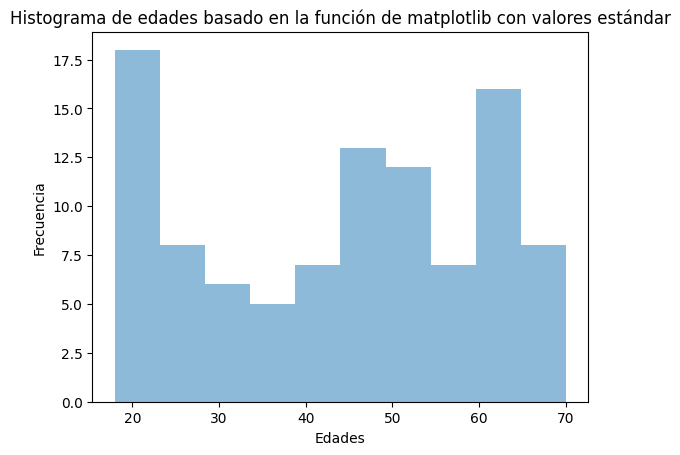

In [16]:
import matplotlib.pyplot as plt
plt.hist(edades, alpha=0.5)
plt.title('Histograma de edades basado en la función de matplotlib con valores estándar')

plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.show()

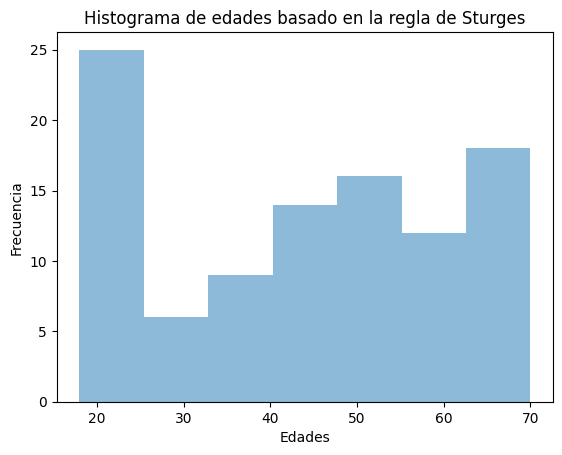

In [18]:
#Histograma basado en la tabla de frecuencia
plt.hist(df['Edad'], bins=k, alpha=0.5)
plt.title('Histograma de edades basado en la regla de Sturges')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.show()